In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/clean_data

/content/drive/MyDrive/clean_data


In [3]:
%ls

Competition.csv   Ends.csv        logs/         runner.py         Teams.csv
Competitors.csv   full_array.csv  Main.Rmd      Stones.csv        Untitled.Rmd
CurlingCNN.ipynb  Games.csv       __pycache__/  stones_final.csv


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset

In [5]:
nndata = pd.read_csv('stones_final.csv')

/tmp/ipython-input-1751436126.py:1: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  nndata = pd.read_csv('stones_final.csv')


In [6]:
cols = [f"stone_{i}_{axis}" for i in range(1, 13) for axis in ["x", "y"]]
cols.append('Team1_Hammer')
cols.append('EndID')
cols.append('ShotID')
# Subset the DataFrame
nninput = nndata[cols]

In [7]:
resets = nninput["EndID"] < nninput["EndID"].shift()

# Cumulative count of resets (starts at 0, increases each time we reset)
block_id = resets.cumsum()

# Combine block ID with original col to make continuous numbering
nninput["EndID_full"] = nninput["EndID"] + block_id.max() * block_id / block_id.max()  # ← old idea, but let's simplify
nninput["EndID_full"] = nninput["EndID"] + block_id.max() * 0  # redundant line to illustrate
nninput["EndID_full"] = nninput["EndID"] + block_id

/tmp/ipython-input-3809179058.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nninput["EndID_full"] = nninput["EndID"] + block_id.max() * block_id / block_id.max()  # ← old idea, but let's simplify
/tmp/ipython-input-3809179058.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nninput["EndID_full"] = nninput["EndID"] + block_id.max() * 0  # redundant line to illustrate
/tmp/ipython-input-3809179058.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [8]:
for col in nninput.columns[:-4]:
    nninput[col] = pd.to_numeric(nninput[col], errors='coerce').astype('Int64')

/tmp/ipython-input-4278348394.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nninput[col] = pd.to_numeric(nninput[col], errors='coerce').astype('Int64')


In [36]:
#filter to shotId > 5
nninput = nninput[nninput['ShotID'] > 5]

In [37]:
nninput

,stone_1_x,stone_1_y,stone_2_x,stone_2_y,stone_3_x,stone_3_y,stone_4_x,stone_4_y,stone_5_x,stone_5_y,...,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y,Team1_Hammer,EndID,ShotID,EndID_full
5,963,1657,<NA>,<NA>,671,713,600,798,<NA>,<NA>,...,590,1164,<NA>,<NA>,<NA>,<NA>,False,1,6,1
6,963,1657,<NA>,<NA>,671,684,600,798,830,648,...,590,1164,<NA>,<NA>,<NA>,<NA>,False,1,7,1
7,963,1657,<NA>,<NA>,671,684,600,798,830,648,...,590,1164,671,850,<NA>,<NA>,False,1,8,1
8,963,1657,<NA>,<NA>,671,684,600,798,830,648,...,590,1164,671,850,<NA>,<NA>,False,1,9,1
9,963,1657,<NA>,<NA>,671,684,600,798,830,648,...,590,1164,671,850,1031,496,False,1,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26365,<NA>,<NA>,<NA>,<NA>,429,179,<NA>,<NA>,<NA>,<NA>,...,500,567,<NA>,<NA>,<NA>,<NA>,False,7,6,350
26366,<NA>,<NA>,<NA>,<NA>,429,179,<NA>,<NA>,760,1152,...,500,567,<NA>,<NA>,<NA>,<NA>,False,7,7,350
26367,<NA>,<NA>,<NA>,<NA>,429,179,<NA>,<NA>,<NA>,<NA>,...,500,567,272,797,<NA>,<NA>,False,7,8,350
26368,<NA>,<NA>,<NA>,<NA>,429,179,<NA>,<NA>,<NA>,<NA>,...,500,567,272,797,<NA>,<NA>,False,7,9,350


In [38]:
np.arange(len(nninput))

array([    0,     1,     2, ..., 13182, 13183, 13184])

In [79]:
sheet_id = np.arange(len(nninput))[:10000]
sheets = {}
for id in sheet_id:
    sheets[f"sheet_{id}"] = np.zeros((2, 150, 300), dtype=np.int8)

In [40]:
sheets["sheet_0"]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=int8)

In [41]:
POOL = 10  # pooling from 1500→150 and 3000→300

for i in range(10000):
    sheet = sheets[f"sheet_{i}"]   # shape: (2,150,300)
    row = nninput.iloc[i]

    # determine team channels
    if not row['Team1_Hammer']:
        ch_team1, ch_team2 = 0, 1
    else:
        ch_team1, ch_team2 = 1, 0

    # loop over the 12 stones
    for s in range(1, 13):
        x_col = f"stone_{s}_x"
        y_col = f"stone_{s}_y"

        x = row[x_col]
        y = row[y_col]

        if pd.isna(x) or pd.isna(y):
            continue

        # original pixel coords (1500×3000)
        x = int(x)
        y = int(y)

        # pooled coords (150×300)
        px = x // POOL      # 0–
        py = y // POOL      # 0–299

        # team assignment
        if s <= 6:
            sheet[ch_team1, px, py] = 1
        else:
            sheet[ch_team2, px, py] = 1

In [42]:
np.max(sheets['sheet_10'])

np.int8(1)

In [49]:
nndata['Result_Team1'][:20000]

,Result_Team1
0,-1
1,-1
2,-1
3,-1
4,-1
...,...
19995,-1
19996,-1
19997,-1
19998,-1


In [70]:
Team1_Won = pd.Series(
    [1 if x > 0 else 0 for x in nndata['Result_Team1'][:20000]]
).astype('category')

In [71]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [72]:
tensor_sheets = {}

for name, sheet in sheets.items():
    sheet = np.array(sheet, dtype=float)
    tensor_sheets[name] = torch.tensor(sheet, dtype=torch.float32)

In [73]:
Team1_Won = Team1_Won[:20000]

In [74]:
Team1_Won

,0
0,0
1,0
2,0
3,0
4,0
...,...
19995,0
19996,0
19997,0
19998,0


In [75]:
pattern = np.tile(np.concatenate([np.zeros(5, dtype=bool), np.ones(5, dtype=bool)]), int(np.ceil(len(Team1_Won)/10)))[:len(Team1_Won)]

# Apply
Team1_Won = Team1_Won[pattern]
Team1_Won = np.array(Team1_Won, dtype=int)

In [76]:
labels = torch.tensor(Team1_Won, dtype=torch.float32)

In [77]:
tensor_sheets['sheet_1600'].shape

torch.Size([2, 150, 300])

In [78]:
labels.shape

torch.Size([10000])

In [80]:
sheet_list = [tensor_sheets[f"sheet_{i}"] for i in range(10000)]

# Stack into one 4D tensor: (N, C, H, W)
inputs = torch.stack(sheet_list)

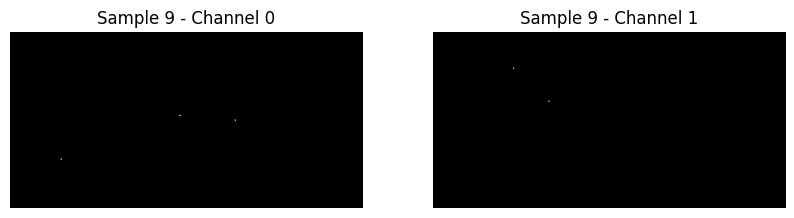

In [81]:
import matplotlib.pyplot as plt
%matplotlib inline
def show_sample(batch, index=0):
    img = batch[index]      # [2, H, W]

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    for c in range(2):
        axs[c].imshow(img[c].cpu().numpy(), cmap='gray')
        axs[c].set_title(f"Sample {index} - Channel {c}")
        axs[c].axis('off')

    plt.show()

show_sample(inputs, 9)

In [82]:
x_train  = inputs[:9900]
x_test = inputs[9900:]
y_train = labels[:9900]
y_test = labels[9900:]

In [83]:
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

/tmp/ipython-input-4238191440.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.float32)


In [84]:
x_train.shape

torch.Size([9900, 2, 150, 300])

In [31]:
!pip install catalyst

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.4 MB/s eta 0:00:00
Requested catalyst from https://files.pythonhosted.org/packages/05/09/36a4acd1c3112f2e2da74f4340778100a205ecb59166be00dc6287f3364f/catalyst-22.4-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    scikit-image (<0.19.0>=0.16.1) ; extra == 'all'
                 ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.8 MB/s eta 0:00:00
Requested catalyst from https://files.pythonhosted.org/packages/28/4f/380899b95b45f02182e7163b4e9be4749724c898886d70009168bfd07409/catalyst-22.2.1-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    scikit-image (<0.19.0>=0.16.1) ; extra == 'all'
                 ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [85]:
from sklearn.model_selection import KFold
import collections
import collections.abc
collections.MutableMapping = collections.abc.MutableMapping
from catalyst import dl, metrics
from catalyst.utils import set_global_seed
from catalyst.callbacks.checkpoint import CheckpointCallback

from catalyst import dl, metrics, utils

class CustomRunner(dl.Runner):
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.valid_losses = []

    def on_loader_start(self, runner):
        super().on_loader_start(runner)
        self.meters = {
            key: metrics.AdditiveValueMetric(compute_on_call=False)
            for key in ["loss"]
        }

    def handle_batch(self, batch):
        x, y = batch
        #x = x.view(len(x), -1)
        y_pred = self.model(x)
        loss = self.criterion(y_pred, y)
        self.batch_metrics.update({"loss": loss})

        for key in ["loss"]:
            self.meters[key].update(self.batch_metrics[key].item(), self.batch_size)

        if self.is_train_loader:
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

    def on_loader_end(self, runner):
        for key in ["loss"]:
            self.loader_metrics[key] = self.meters[key].compute()[0]
        if self.loader_key == "train":
            self.train_losses.append(self.loader_metrics["loss"])
        elif self.loader_key == "valid":
            self.valid_losses.append(self.loader_metrics["loss"])
        super().on_loader_end(runner)

In [87]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NeuralNetCNN(nn.Module):
    def __init__(self, in_channels=2, num_outputs=1):
        super(NeuralNetCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=5, stride=2, padding=2)  # (B,16,750,1500)
        self.gn1 = nn.GroupNorm(4, 16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2)           # (B,32,375,750)
        self.gn2 = nn.GroupNorm(8, 32)


        # Adaptive pooling to reduce HxW
        self.global_pool = nn.AdaptiveAvgPool2d((4,4))  # (B,128,1,1)

        # Fully connected layers
        self.fc1 = nn.Linear(32*4*4, 16)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(16, num_outputs)

        # Output activation for binary classification

    def forward(self, x):
        x = F.leaky_relu(self.gn1(self.conv1(x)), 0.1)
        x = F.leaky_relu(self.gn2(self.conv2(x)), 0.1)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = F.leaky_relu(self.fc1(x), 0.1)
        x = self.fc2(x)
        return x

In [88]:
print(y_train.min(), y_train.max(), y_train.dtype)


tensor(0.) tensor(1.) torch.float32


In [ ]:
kf = KFold(n_splits=5, shuffle=False)
fold_metrics = []

# Dataset must be CPU tensors
dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
)

set_global_seed(123)

for fold, (train_idx, val_idx) in enumerate(kf.split(x_train)):
    print(f"Fold {fold+1}")

    # Create datasets
    train_dataset = Subset(dataset, train_idx)
    val_dataset = Subset(dataset, val_idx)

    # IMPORTANT: num_workers = 0
    train_loader = DataLoader(train_dataset, batch_size=32, num_workers=0, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, num_workers=0, shuffle=False)

    # RECREATE model & optimizer inside fold loop
    model = NeuralNetCNN(2, 1)
    model = model.to("cuda")                     # move model to GPU

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.BCEWithLogitsLoss()

    runner = CustomRunner()

    runner.train(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        loaders={"train": train_loader, "valid": val_loader},
        num_epochs=50,
        logdir=f"./logs/fold_{fold}",
        valid_loader="valid",
        valid_metric="loss",
        minimize_valid_metric=True,
        seed=123
    )

    fold_metrics.append(runner.loader_metrics["loss"])

/tmp/ipython-input-1852449864.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(x_train, dtype=torch.float32),


Fold 1


/usr/local/lib/python3.12/dist-packages/catalyst/core/runner.py:716: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  k: runner.engine.sync_tensor(torch.tensor(v, device=runner.device), "mean")


train (1/50) loss: 0.6949175654035628
valid (1/50) loss: 0.6933612375548392
* Epoch (1/50) 
train (2/50) loss: 0.6935422337416446
valid (2/50) loss: 0.693406103957783
* Epoch (2/50) 
train (3/50) loss: 0.6936064000081533
valid (3/50) loss: 0.69360115082577
* Epoch (3/50) 
train (4/50) loss: 0.6933313015735509
valid (4/50) loss: 0.6939463755097052
* Epoch (4/50) 
train (5/50) loss: 0.6937624517113274
valid (5/50) loss: 0.6934664433652703
* Epoch (5/50) 
train (6/50) loss: 0.6938357586812496
valid (6/50) loss: 0.6935995879799428
* Epoch (6/50) 
train (7/50) loss: 0.6934748577349115
valid (7/50) loss: 0.6933642802816447
* Epoch (7/50) 
train (8/50) loss: 0.6939071703438807
valid (8/50) loss: 0.6945523701532924
* Epoch (8/50) 
train (9/50) loss: 0.6934311510336516
valid (9/50) loss: 0.6934107613081881
* Epoch (9/50) 
train (10/50) loss: 0.6917250874066583
valid (10/50) loss: 0.6936459457031408
* Epoch (10/50) 
train (11/50) loss: 0.6899353205555617
valid (11/50) loss: 0.6949505773457612
* 

In [ ]:
model.eval()
x_test = x_test.to(device)
with torch.no_grad():
    outputs = model(x_test)       # logits
    probs = torch.sigmoid(outputs)  # probabilities
    preds = (probs >= 0.5).long()

In [ ]:
y_test

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
preds

tensor([[0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [1],
        [1],
        [0],
        [1],
        [1],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],

In [ ]:
y_test = y_test.to(device)


In [ ]:
correct = (preds.squeeze() == y_test.squeeze()).sum().item()

# Compute accuracy
accuracy = correct / y_test.size(0)

print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 58.00%
